# v1_fcnn — fully connected sin codificación espacial

Wrapper visual del paquete `Models/v1_fcnn/`. La red aprende

$$ f(\mathbf{B}_{\text{sens}}) \;\longrightarrow\; \mathbf{B}_{\text{grid}} $$

Una FCN plana recibe los `I·3` valores de sensores aplanados y devuelve **todo** el campo de la grilla aplanado `(J·3,)` en mT. Sin coordenadas como input, sin losses físicas. Loss: MSE sobre `B / b_scale`.

Es el baseline más simple de la progresión (v1 → v2_pinn agrega `(x,y,z)` y losses Maxwell/TV). Reusa el mismo HDF5 que v2.

In [1]:
# Celda A — path setup
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd() / "PMDKernel" / "Python",
                  Path.cwd().parent / "Python"):
    if (candidate / "Models" / "v1_fcnn").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

print("path OK:", sys.path[0])

path OK: c:\Users\Poney\Desktop\Ipre\PMDKernel\Python


In [2]:
# Celda B — numpy/pandas/matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("numpy/pandas/matplotlib OK")

numpy/pandas/matplotlib OK


In [3]:
# Celda C — torch
import torch
print(f"torch {torch.__version__}")

torch 2.5.1+cu121


In [4]:
# Celda D — chequeo CUDA (suele colgar si hay un proceso CUDA zombie de un kernel previo)
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device name   : {torch.cuda.get_device_name(0)}")

cuda available: True
device name   : NVIDIA GeForce RTX 2050


In [5]:
# Celda E — pytorch_lightning (cold import puede tardar 30-90s)
import pytorch_lightning as pl
print(f"lightning {pl.__version__}")

lightning 2.6.1


In [6]:
# Celda F — módulos del proyecto v1_fcnn
from Models.v1_fcnn import data
from Models.v1_fcnn.model import LitFCNN, count_params
from Models.v1_fcnn.train import train as fcnn_train
from Models.v1_fcnn.metrics import evaluate, report
print("v1_fcnn OK")

v1_fcnn OK


In [7]:
# Celda G — SEED + device
SEED = 42
pl.seed_everything(SEED, workers=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

Seed set to 42


device: cuda


## 1. Configuración

In [ ]:
REPO_ROOT = Path("..").resolve()
H5_PATH   = REPO_ROOT / "data" / "datasets" / "v1_xy100_z225_step10_n5000.h5"

VAL_FRAC  = 0.15
TEST_FRAC = 0.15

# Arquitectura FCNN — pirámide incremental hasta 2048.
# La última capa Linear(hidden_last, J*3) domina el conteo (~98% de los params).
# Pyramid [256, 512, 1024, 2048] → ~127M params totales, ~125M en la última.
# Regularización moderada para compensar P/N ~ 360k con N_train=350.
HIDDEN_LAYERS = [256, 512, 1024, 2048]

# Activación: GELU > ReLU para regresión signada (B con valores ±).
# - Evita dying-ReLU (smooth, gradiente nunca exactamente 0).
# - Permite activaciones internas levemente negativas → media ≈ 0.
# - Derivada continua → optimización más estable.
ACTIVATION    = "gelu"        # 'relu' | 'gelu' | 'silu' | 'tanh'
DROPOUT       = 0.1

BATCH_SIZE    = 32
N_EPOCHS      = 100
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 20

NUM_WORKERS = 0       # Windows local: 0; cluster Linux: 4-8 + pin_memory=True
PIN_MEMORY  = False

RUN_TAG = f"v1_fcnn_{H5_PATH.stem}"
OUT_DIR = REPO_ROOT / "python" / "Models" / "v1_fcnn" / "logs" / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"H5_PATH = {H5_PATH}")
print(f"RUN_TAG = {RUN_TAG}")
print(f"OUT_DIR = {OUT_DIR}")

## 2. Carga de metadatos

In [11]:
ds = data.load_dataset_metadata(H5_PATH)

n_in  = ds["I"] * 3       # B_sens flatten
n_out = ds["J"] * 3       # B_grid flatten

print(f"Muestras (N)   : {ds['N']}")
print(f"Sensores (I)   : {ds['I']}  → input al modelo: I*3 = {n_in}")
print(f"Grilla (J)     : {ds['Nx']} x {ds['Ny']} x {ds['Nz']} = {ds['J']}  → output: J*3 = {n_out}")
print(f"Rango x        : [{ds['grid_x'].min():.0f}, {ds['grid_x'].max():.0f}] mm")
print(f"Rango y        : [{ds['grid_y'].min():.0f}, {ds['grid_y'].max():.0f}] mm")
print(f"Rango z        : [{ds['grid_z'].min():.0f}, {ds['grid_z'].max():.0f}] mm")
print(f"Perturb        : kind={ds['attrs'].get('kind')}, sigma_deg={ds['attrs'].get('sigma_deg')}")

Muestras (N)   : 500
Sensores (I)   : 180  → input al modelo: I*3 = 540
Grilla (J)     : 21 x 21 x 46 = 20286  → output: J*3 = 60858
Rango x        : [-100, 100] mm
Rango y        : [-100, 100] mm
Rango z        : [-225, 225] mm
Perturb        : kind=b'both', sigma_deg=1.0


## 3. Split + scalers + DataLoaders

Normalización:

- **Sensores** (input): `StandardScaler` per-feature → media 0, std 1 por feature.
- **B target**: dividido por `b_scale = RMS(B_train)` único → escalar isotrópico, preserva dirección del campo, relación Bx:By:Bz, y estructura espacial.

Sin `coord_scale` (v1 no usa coords).

In [12]:
splits = data.split_indices(ds["N"], val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED)
stats  = data.compute_train_stats(H5_PATH, splits["train"], chunk=64)
x_scaler = stats["x_scaler"]
b_scale  = stats["b_scale"]

loader_kwargs = dict(batch_size=BATCH_SIZE,
                     x_scaler=x_scaler,
                     b_scale=b_scale,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

loader_tr = data.make_loader(H5_PATH, splits["train"], shuffle=True,  **loader_kwargs)
loader_va = data.make_loader(H5_PATH, splits["val"],   shuffle=False, **loader_kwargs)

print(f"train={splits['n_train']}   val={splits['n_val']}   test={splits['n_test']}")
print(f"x_scaler:   mean range [{x_scaler.mean_.min():.3e}, {x_scaler.mean_.max():.3e}]")
print(f"            scale range [{x_scaler.scale_.min():.3e}, {x_scaler.scale_.max():.3e}]")
print(f"b_scale   = {b_scale:.4f} mT      (RMS de B_grid sobre train)")

sensors_b, b_b = next(iter(loader_tr))
print(f"\nbatch shapes: sensors={tuple(sensors_b.shape)}, B={tuple(b_b.shape)}")
print(f"sensors range: [{sensors_b.min():.3f}, {sensors_b.max():.3f}]  (z-score)")
print(f"B range      : [{b_b.min():.3f}, {b_b.max():.3f}]   (B / b_scale)")

train=350   val=75   test=75
x_scaler:   mean range [-1.933e+01, 3.068e+01]
            scale range [9.589e-02, 5.544e-01]
b_scale   = 30.0049 mT      (RMS de B_grid sobre train)

batch shapes: sensors=(32, 540), B=(32, 60858)
sensors range: [-4.239, 3.354]  (z-score)
B range      : [-2.000, 1.840]   (B / b_scale)


## 4. Modelo FCNN

In [11]:
lit_model = LitFCNN(
    n_in=n_in, n_out=n_out, hidden_layers=HIDDEN_LAYERS,
    activation=ACTIVATION, dropout=DROPOUT,
    lr=LR, weight_decay=WEIGHT_DECAY,
    b_scale=b_scale,
)
print(lit_model)
print(f"\nParámetros entrenables: {count_params(lit_model):,}")

LitFCNN(
  (net): FCNN(
    (net): Sequential(
      (0): Linear(in_features=540, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=512, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=512, out_features=1024, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.1, inplace=False)
      (9): Linear(in_features=1024, out_features=2048, bias=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=2048, out_features=60858, bias=True)
    )
  )
  (train_mse): MeanSquaredError()
  (val_mse): MeanSquaredError()
)

Parámetros entrenables: 127,592,634


## 5. Entrenamiento

In [12]:
trainer = fcnn_train(
    lit_model, loader_tr, loader_va,
    n_epochs=N_EPOCHS, patience=PATIENCE,
    ckpt_dir=OUT_DIR, run_tag=RUN_TAG,
)
best_ckpt_path = trainer.checkpoint_callback.best_model_path
log_dir = trainer.logger.log_dir
print(f"\nMejor checkpoint: {best_ckpt_path}")
print(f"Logs (CSV)      : {log_dir}/metrics.csv")

lit_model = LitFCNN.load_from_checkpoint(best_ckpt_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 2050') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
c:\Users\Poney\Desktop\Ipre\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\Poney\Desktop\Ipre\PMDKernel\data\modelos exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
-----------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Poney\Desktop\Ipre\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Poney\Desktop\Ipre\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Mejor checkpoint: C:\Users\Poney\Desktop\Ipre\PMDKernel\data\modelos\v1_fcnn_v1_xy100_z225_step10_n500.ckpt
Logs (CSV)      : C:\Users\Poney\Desktop\Ipre\PMDKernel\data\modelos/logs\v1_fcnn_v1_xy100_z225_step10_n500\version_0/metrics.csv


c:\Users\Poney\Desktop\Ipre\.venv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
best_ckpt_path = OUT_DIR / f"{RUN_TAG}.ckpt"
log_dir        = OUT_DIR / "version_0"

assert best_ckpt_path.exists(), f"No existe el ckpt: {best_ckpt_path}"
assert (log_dir / "metrics.csv").exists(), f"No existe metrics.csv en: {log_dir}"

lit_model = LitFCNN.load_from_checkpoint(str(best_ckpt_path))
print(f"ckpt cargado : {best_ckpt_path}")
print(f"log_dir      : {log_dir}")


Columnas en CSV: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'train_mse_norm_epoch', 'train_mse_norm_step', 'val_loss', 'val_mse_norm']


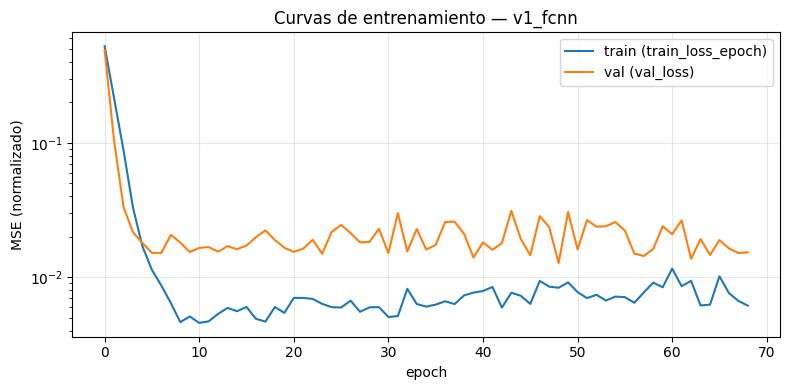

In [17]:

metrics_csv = Path(log_dir) / "metrics.csv"
df = pd.read_csv(metrics_csv)
print("Columnas en CSV:", df.columns.tolist())

# Lightning a veces guarda con suffix `_epoch` (cuando on_step=on_epoch=True
# implícitamente desde training_step), a veces sin (cuando on_step=False).
def _pick(*candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

train_col = _pick("train_loss_epoch", "train_loss")
val_col   = _pick("val_loss_epoch",   "val_loss")

if train_col is None:
    raise RuntimeError(f"No encontré columna de train loss en {df.columns.tolist()}")

# Lightning escribe varias filas por epoch (una por step + una de epoch-end).
# Tomamos el primer valor non-NaN por epoch para cada métrica.
def _first_valid(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else None

cols = [c for c in (train_col, val_col) if c is not None]
hist = (df[["epoch", *cols]]
        .groupby("epoch")
        .agg({c: _first_valid for c in cols})
        .reset_index())

plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist[train_col], label=f"train ({train_col})")
if val_col is not None:
    plt.plot(hist["epoch"], hist[val_col], label=f"val ({val_col})")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE (normalizado)")
plt.title("Curvas de entrenamiento — v1_fcnn")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Evaluación final — métricas físicas sobre el volumen

Reconstruimos `B_pred` flat → `(Nx, Ny, Nz, 3)` y aplicamos diferencias finitas
para chequear coherencia física. Cuatro métricas:

- **∇·B** → 0 (Gauss).
- **∇×B** → 0 (Ampère sin corrientes, válido en aire/vacío).
- **∇²B** → 0 (campo armónico fuera de fuentes).
- **TV** → matchea TV(truth). El campo de un dipolo es C∞ smooth fuera del
  imán, y B0 en MRI tiene un requisito de homogeneidad por especificación. El
  target NO es cero (el campo varía físicamente entre centro y bordes), es
  el TV del ground truth.

Las cuatro se computan sobre **predicción Y ground truth** con el mismo operador
FD. La métrica honesta es el ratio `pred/true`: ≈1× = la red matchea al campo
verdadero, >>1× = rompe esa propiedad meaningful.

RMSE/MAE en mT se mantienen como sanity check de fidelidad.

In [18]:
grid_metadata = {
    "Nx": ds["Nx"], "Ny": ds["Ny"], "Nz": ds["Nz"],
    "grid_x": ds["grid_x"], "grid_y": ds["grid_y"], "grid_z": ds["grid_z"],
}
print(f"Grid: {ds['Nx']}x{ds['Ny']}x{ds['Nz']}   "
      f"spacings dx={ds['grid_x'][1]-ds['grid_x'][0]:.1f}  "
      f"dy={ds['grid_y'][1]-ds['grid_y'][0]:.1f}  "
      f"dz={ds['grid_z'][1]-ds['grid_z'][0]:.1f}  mm")

eval_kwargs = dict(grid_metadata=grid_metadata, rmse_per_component=True)

m_tr = evaluate(lit_model, H5_PATH, splits["train"], x_scaler, b_scale, DEVICE, **eval_kwargs)
m_va = evaluate(lit_model, H5_PATH, splits["val"],   x_scaler, b_scale, DEVICE, **eval_kwargs)
m_te = evaluate(lit_model, H5_PATH, splits["test"],  x_scaler, b_scale, DEVICE, **eval_kwargs)

report("train", m_tr)
report("val",   m_va)
report("test",  m_te)

Grid: 21x21x46   spacings dx=10.0  dy=10.0  dz=10.0  mm
[train]  RMSE=1.6784e+00 mT   MAE=1.2121e+00 mT   (N=350)
          RMSE Bx=8.2241e-01  By=3.1558e+00  Bz=1.0436e+00  mT
          ∇·B    pred=1.9406e-01  true=1.8402e-01  ratio=1.05×   [mT/mm]
          ‖∇×B‖  pred=1.2294e-01  true=8.8218e-02  ratio=1.39×   [mT/mm]
          ‖∇²B‖  pred=4.3699e-02  true=1.5552e-02  ratio=2.81×   [mT/mm²]
          TV     pred=2.8415e+00  true=2.5133e+00  ratio=1.13×   [mT]
[  val]  RMSE=2.8400e+00 mT   MAE=1.9544e+00 mT   (N=75)
          RMSE Bx=8.9239e-01  By=5.6623e+00  Bz=1.2638e+00  mT
          ∇·B    pred=1.8299e-01  true=1.8389e-01  ratio=1.00×   [mT/mm]
          ‖∇×B‖  pred=1.1592e-01  true=8.8039e-02  ratio=1.32×   [mT/mm]
          ‖∇²B‖  pred=4.1205e-02  true=1.5543e-02  ratio=2.65×   [mT/mm²]
          TV     pred=2.6794e+00  true=2.5121e+00  ratio=1.07×   [mT]
[ test]  RMSE=3.2598e+00 mT   MAE=2.2073e+00 mT   (N=75)
          RMSE Bx=9.2651e-01  By=6.6045e+00  Bz=1.3723e+00  mT
   

## 7. Guardar scalers + metadata

El `ModelCheckpoint` ya guardó el `.ckpt` (con `b_scale` adentro como buffer).
Acá persistimos lo que Lightning no guarda: scaler de sensores (StandardScaler
fitted), índices del split, y las métricas finales.

In [19]:
aux_path = OUT_DIR / f"{RUN_TAG}_aux.pt"
torch.save({
    "x_scaler":    x_scaler,
    "x_mean":      x_scaler.mean_.astype(np.float32),
    "x_scale":     x_scaler.scale_.astype(np.float32),
    "b_scale":     float(b_scale),
    "splits":      splits,
    "metrics":     {"train": m_tr, "val": m_va, "test": m_te},
    "hparams": {
        "hidden_layers": HIDDEN_LAYERS,
        "activation":    ACTIVATION,
        "dropout":       DROPOUT,
        "batch_size":    BATCH_SIZE,
    },
    "h5_path":   str(H5_PATH),
    "ckpt_path": best_ckpt_path,
}, aux_path)
print(f"Best checkpoint Lightning : {best_ckpt_path}")
print(f"Scalers + metadata        : {aux_path}")

Best checkpoint Lightning : C:\Users\Poney\Desktop\Ipre\PMDKernel\data\modelos\v1_fcnn_v1_xy100_z225_step10_n500.ckpt
Scalers + metadata        : C:\Users\Poney\Desktop\Ipre\PMDKernel\data\modelos\v1_fcnn_v1_xy100_z225_step10_n500_aux.pt


In [20]:
print("Columnas:", df.columns.tolist())
print("\nÚltimas 5 filas de hist:")
print(hist.tail())
print("\nValores mínimos por columna:")
print(hist.min(numeric_only=True))

Columnas: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'train_mse_norm_epoch', 'train_mse_norm_step', 'val_loss', 'val_mse_norm']

Últimas 5 filas de hist:
    epoch  train_loss_epoch  val_loss
64     64          0.006234  0.014636
65     65          0.010151  0.018867
66     66          0.007606  0.016380
67     67          0.006652  0.015119
68     68          0.006130  0.015298

Valores mínimos por columna:
epoch               0.000000
train_loss_epoch    0.004561
val_loss            0.012757
dtype: float64
